# Affine parametric Darcy problem: TT-PINN with Adam (first-order baseline)

Companion notebook to the manuscript, Section *Parametric Darcy problem*. It reproduces the TT-Adam
baseline for the affine coefficient, panel (a) of the TT-Adam figure. Problem, TT ansatz,
factor grids, initialization, error measures and plots are identical to the Gauss–Newton notebook
(`Affine_Darcy_TT_GaussNewton_ablation.ipynb`); only the parameter update differs.

## Problem

$$
-\nabla_x\cdot\bigl(\kappa(x,\xi)\,\nabla_x u(x,\xi)\bigr)=f(x,\xi)\quad\text{in }\Omega\times\Xi,
\qquad u=0\quad\text{on }\partial\Omega\times\Xi,
$$

with $\Omega=(0,1)^{d_x}$ and $\Xi=(-1,1)^{d_\xi}$. We use $d_x=3$ and $d_\xi=25$, so the TT-PINN
has $d=28$ coordinates.

The permeability is affine in the parameters,

$$
\kappa_{\rm aff}(x,\xi)=\bar\kappa+\varepsilon\sum_{j=1}^{d_\xi}\xi_j\sqrt{\lambda_j}\prod_{m=1}^{d_x}\cos(\pi j x_m),
\qquad \lambda_j=j^{-2},\quad \bar\kappa=1,\quad \varepsilon=0.1 .
$$

The forcing $f$ is manufactured from the exact solution
$u^\star_{\rm aff}(x,\xi)=\prod_{m}\sin(\pi x_m)\,\bigl(1+\sum_{j}\xi_j\bigr)$, which has TT rank two.

## Method

- **TT-PINN.** $u_\theta(z)=G_1(z_1)\cdots G_d(z_d)$ with TT ranks $(1,2,\dots,2,1)$. Each core
  is a $\tanh$ network $1\to128\to128\to128\to r_{m-1}r_m$, giving $P=945\,772$ parameters. The
  physical cores are multiplied by $\sqrt{30}\,x(1-x)$, which enforces the boundary condition exactly.
- **Collocation.** One factor grid of $n=64$ uniformly drawn points per coordinate, fixed during
  training. The tensor grid ($64^{28}$ points) is never formed: residuals, loss and derivatives are
  computed by one-dimensional TT contractions.
- **Gradient.** The loss gradient is evaluated in the same compressed TT form as the
  Gauss–Newton quantities, $\nabla\widehat{\mathcal L}(\theta)=\mathsf C^\top\rho_{\rm c}$, and is
  checked against reverse-mode automatic differentiation.
- **Optimizer.** Adam with $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$ and a learning rate
  decaying exponentially from $10^{-3}$ to $10^{-5}$ over 50,000 iterations.
- **Ablation.** 10 seeds; the seeds, factor grids and initial TT coincide with the Gauss–Newton
  ablation. The relative $H^1$ error is evaluated every 1000 iterations and excluded from the timings.

**Notebook layout.** Engine and plotting helpers $\to$ hyperparameters and one validation run
$\to$ consistency checks $\to$ seed ablation, figures and export (CSV tables, JSON histories).

## TT engine

Same problem class, TT ansatz, factor grids and error routines as in the Gauss–Newton notebook.
The Gauss–Newton solver is replaced by `loss_and_gradient` (loss and compressed gradient) and the
Adam trainer (`make_trainer`, `run`). The histories use the same keys as in the Gauss–Newton
notebook, so the plotting helpers are shared; here `step` stores the learning rate.

In [ ]:
from dataclasses import dataclass, asdict, replace
from functools import partial
from pathlib import Path
import gc
import json
import time

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax import random, vmap, lax, jit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PI = jnp.pi
tree_map = jax.tree_util.tree_map


def bc_scale_of(mode):
    mode = mode.lower()
    if mode == 'l2_unit':
        return float(np.sqrt(30.0))
    if mode == 'max_unit':
        return 4.0
    if mode == 'sine_match':
        return float(np.sqrt(15.0))
    raise ValueError(f'unknown bc_normalization: {mode}')


def tt_ranks(d, r):
    """TT ranks (r_0, ..., r_d) with r_0 = r_d = 1."""
    return (1,) + (int(r),) * (d - 1) + (1,)


def compressed_gradient_dimension(d_x, d_xi, n, rank):
    """N_eff^ch of the compressed gradient grad L = C^T rho_c:

        N_eff^ch = sum_s L_s n_s k_s,  L_s = 3 (s <= d_x), 1 (s > d_x),
        k_s = r_{s-1} r_s.
    """
    d = d_x + d_xi
    ranks = tt_ranks(d, rank)
    ks = [ranks[s - 1] * ranks[s] for s in range(1, d + 1)]
    return int(sum((3 if s <= d_x else 1) * n * ks[s - 1] for s in range(1, d + 1)))


# ======================================================================
# Slot runs: consecutive slots with identical local shapes.
#   {1} (1 x r), {2..d_x}, {d_x+1..d-1} (r x r), {d} (r x 1)
# ======================================================================
@dataclass(frozen=True)
class SlotRun:
    start: int
    stop: int
    physical: bool
    k: int                     # k_s
    L: int                     # |Lambda_s|
    units: tuple               # active entries a_s, flat in the padded c x c core
    n: int
    P_slot: int                # P_s

    @property
    def length(self):
        return self.stop - self.start

    @property
    def N_slot(self):
        return self.L * self.n * self.k


def build_slot_runs(d, d_x, c, n, widths):
    hidden = 0
    sizes = (1,) + tuple(widths)
    for a, b in zip(sizes[:-1], sizes[1:]):
        hidden += a * b + b
    w_in = widths[-1] if widths else 1
    ranks = tt_ranks(d, c)
    signatures = [
        (s < d_x, tuple(a * c + b for a in range(ranks[s]) for b in range(ranks[s + 1])))
        for s in range(d)
    ]
    runs, s = [], 0
    while s < d:
        e = s
        while e < d and signatures[e] == signatures[s]:
            e += 1
        physical, units = signatures[s]
        k = len(units)
        runs.append(SlotRun(start=s, stop=e, physical=physical, k=k, L=3 if physical else 1,
                            units=units, n=n, P_slot=hidden + w_in * k + k))
        s = e
    return tuple(runs)


@dataclass(frozen=True)
class Config:
    # Affine Darcy problem: d = d_x + d_xi.
    d_phys: int = 3                      # d_x
    d_param: int = 25                    # d_xi
    kappa_bar: float = 1.0
    eps: float = 0.1
    kl_decay: float = 2.0                # lambda_j = j^{-kl_decay}
    bc_normalization: str = 'l2_unit'    # ell_bc(x) = sqrt(30) x (1-x)

    # Factor grids X_s (n_s = n_per_axis points each) and training.
    n_per_axis: int = 64
    iterations: int = 30000
    error_every: int = 100
    seed: int = 0
    n_err: int = 256
    resample_each_iteration: bool = False

    # TT architecture.
    tt_rank: int = 2                     # TT ranks (1, r, ..., r, 1)
    tt_width: int = 128
    tt_hidden: int = 3
    tt_init_mode: str = 'near_identity'
    tt_identity_epsilon: float = 0.5
    tt_global_scale: bool = True

    # Adam.
    adam_lr: float = 1e-3
    adam_lr_final: float = 1e-5          # exponential decay target; = adam_lr for a constant rate
    adam_beta1: float = 0.9
    adam_beta2: float = 0.999
    adam_eps: float = 1e-8

    @property
    def d(self):
        return self.d_phys + self.d_param


class Darcy:
    """Affine Darcy benchmark: kappa_aff = sum_{j=0}^{d_xi} prod_m kappa_{j,m}(z_m)."""

    def __init__(self, cfg):
        self.cfg = cfg
        self.dx, self.dxi, self.d = cfg.d_phys, cfg.d_param, cfg.d
        self.R_kappa = self.dxi + 1                 # R_kappa = d_xi + 1 coefficient modes
        self.R_A = self.dx * (self.dxi + 1)         # operator-term count R_A = d_x (d_xi + 1)
        self.bc_scale = bc_scale_of(cfg.bc_normalization)
        j = jnp.arange(1, self.dxi + 1, dtype=jnp.float64)
        self.j_modes = j
        self.sqrt_lambda = j ** (-0.5 * cfg.kl_decay)   # sqrt(lambda_j), lambda_j = j^{-2}
        self.kappa_lower_bound = float(cfg.kappa_bar - cfg.eps * jnp.sum(self.sqrt_lambda))

    # ------------------------------------------------------------------
    # Univariate coefficient factors kappa_{j,m}, eq. (affine coefficient for TT).
    # ------------------------------------------------------------------
    def kappa_factors(self, m, z):
        """Return kappa_{j,m}(z) and kappa'_{j,m}(z), j = 0..d_xi, shape (R_kappa, n).

        m is the 0-based slot index (m = 0 is the text's m = 1) and may be
        traced; the function is branch-free in m.
          j = 0 : kappa_{0,1} = kappa_bar, kappa_{0,m} = 1 otherwise;
          j >= 1: m = 1           -> eps sqrt(lambda_j) cos(pi j z),
                  2 <= m <= d_x  -> cos(pi j z),
                  m = d_x + j    -> z,
                  otherwise      -> 1.
        Derivatives are only needed (and only used) on physical slots.
        """
        n = z.shape[0]
        dx = self.dx
        jj = self.j_modes[:, None]
        arg = PI * jj * z[None, :]
        amp = jnp.where(m == 0, self.cfg.eps * self.sqrt_lambda, 1.0)[:, None]
        k_phys = amp * jnp.cos(arg)
        dk_phys = -amp * PI * jj * jnp.sin(arg)
        k0_phys = jnp.where(m == 0, self.cfg.kappa_bar, 1.0) * jnp.ones((1, n))

        own = (jnp.arange(1, self.dxi + 1) == m - dx + 1)[:, None]
        k_par = jnp.where(own, z[None, :], jnp.ones((self.dxi, n)))

        phys = m < dx
        kap = jnp.concatenate([
            jnp.where(phys, k0_phys, jnp.ones((1, n))),
            jnp.where(phys, k_phys, k_par),
        ], axis=0)
        dkap = jnp.concatenate([
            jnp.zeros((1, n)),
            jnp.where(phys, dk_phys, jnp.zeros((self.dxi, n))),
        ], axis=0)
        return kap, dkap

    # ------------------------------------------------------------------
    # Pointwise reference quantities (diagnostics and slice plot only).
    # ------------------------------------------------------------------
    @staticmethod
    def exact_factor(z):
        return jnp.sin(PI * z)

    @staticmethod
    def exact_factor_d1(z):
        return PI * jnp.cos(PI * z)

    @staticmethod
    def exact_factor_d2(z):
        return -(PI ** 2) * jnp.sin(PI * z)

    def exact(self, z):
        """u*_aff(x, xi) = prod_m sin(pi x_m) (1 + sum_j xi_j), with grad_x and Laplacian."""
        x, xi = z[:self.dx], z[self.dx:]
        p = self.exact_factor(x)
        p1 = self.exact_factor_d1(x)
        p2 = self.exact_factor_d2(x)
        T = 1.0 + jnp.sum(xi)
        pre = jnp.concatenate([jnp.ones((1,), dtype=x.dtype), jnp.cumprod(p)[:-1]])
        suf = jnp.concatenate([
            jnp.cumprod(p[::-1])[:-1][::-1],
            jnp.ones((1,), dtype=x.dtype),
        ])
        skip = pre * suf
        u = jnp.prod(p) * T
        grad = T * p1 * skip
        lap = T * jnp.sum(p2 * skip)
        return u, grad, lap

    def kappa(self, z):
        x, xi = z[:self.dx], z[self.dx:]
        arg = PI * self.j_modes[:, None] * x[None, :]
        C, S = jnp.cos(arg), jnp.sin(arg)
        coef = self.cfg.eps * self.sqrt_lambda * xi
        kap = self.cfg.kappa_bar + jnp.sum(coef * jnp.prod(C, axis=1))
        pre = jnp.concatenate([jnp.ones((self.dxi, 1)), jnp.cumprod(C, axis=1)[:, :-1]], axis=1)
        suf = jnp.concatenate([
            jnp.cumprod(C[:, ::-1], axis=1)[:, :-1][:, ::-1],
            jnp.ones((self.dxi, 1)),
        ], axis=1)
        dpsi = -PI * self.j_modes[:, None] * S * (pre * suf)
        grad = jnp.einsum('j,jk->k', coef, dpsi)
        return kap, grad

    def forcing(self, z):
        _, grad_u, lap_u = self.exact(z)
        kap, grad_kap = self.kappa(z)
        return -kap * lap_u - jnp.dot(grad_kap, grad_u)

    # ------------------------------------------------------------------
    # Factor grids X_s, eq. (factor_grids).
    # ------------------------------------------------------------------
    def sample_factor_grids(self, key, n):
        unit = random.uniform(key, (self.d, n))
        return unit.at[self.dx:].set(2.0 * unit[self.dx:] - 1.0)

    def midpoint_factor_grids(self, n):
        p = (jnp.arange(n, dtype=jnp.float64) + 0.5) / n
        grids = jnp.tile(p[None, :], (self.d, 1))
        return grids.at[self.dx:].set(2.0 * grids[self.dx:] - 1.0)

    def exact_cores(self, grids):
        """TT cores of u*_aff with ranks (1, 2, ..., 2, 1), padded to 2 x 2.

        Value / first / second derivative channels, shape (d, n, 3, 2, 2).
        Boundary rank one is realized by storing G*_1 in the first row and
        G*_d in the first column of the padded 2 x 2 arrays (all other entries
        zero), i.e. both boundary vectors are e_1.
          physical   : sin(pi z) I_2,
          parametric : [[1, z], [0, 1]],
          last core  : folded with (1, 1)^T, i.e. first column = G*_d (1, 1)^T.
        """
        n = grids.shape[1]
        I = jnp.eye(2, dtype=grids.dtype)
        dx = self.dx

        def one_slot(m, z):
            phys = m < dx
            U0_p = self.exact_factor(z)[:, None, None] * I
            U1_p = self.exact_factor_d1(z)[:, None, None] * I
            U2_p = self.exact_factor_d2(z)[:, None, None] * I
            U0_q = jnp.tile(I[None, :, :], (n, 1, 1)).at[:, 0, 1].set(z)
            zero = jnp.zeros((n, 2, 2), dtype=grids.dtype)
            U0 = jnp.where(phys, U0_p, U0_q)
            U1 = jnp.where(phys, U1_p, zero)
            U2 = jnp.where(phys, U2_p, zero)
            return jnp.stack([U0, U1, U2], axis=1)

        U = vmap(one_slot)(jnp.arange(self.d), grids)          # d, n, 3, 2, 2
        U = U.at[0, :, :, 1, :].set(0.0)                        # r_0 = 1: first row only
        last = U[-1] @ jnp.ones((2,), dtype=grids.dtype)        # G*_d (1, 1)^T
        U = U.at[-1].set(jnp.stack([last, jnp.zeros_like(last)], axis=-1))
        return U


class SeparableAnsatz:
    """TT ansatz with univariate core networks.

      u_theta = G_1(z_1) ... G_d(z_d), G_s : D_s -> R^{r_{s-1} x r_s}, r_0 = r_d = 1.
    Each core is a tanh network 1 -> w -> ... -> w -> k_s; physical cores are
    multiplied by ell_bc(x) = sqrt(30) x (1 - x).  Cores are stored padded to
    r x r.  theta is a tuple with one (run.length, P_s) array per run.
    """

    def __init__(self, cfg, problem):
        self.cfg, self.problem = cfg, problem
        self.d, self.dx = cfg.d, cfg.d_phys
        self.rank = cfg.tt_rank
        self.widths = (cfg.tt_width,) * cfg.tt_hidden
        self.ranks = tt_ranks(self.d, self.rank)
        self.bc_scale = problem.bc_scale
        c = self.rank
        self.left = jnp.eye(c)[0]
        self.right = jnp.eye(c)[0]
        self.runs = build_slot_runs(self.d, self.dx, c, cfg.n_per_axis, self.widths)
        self.P = sum(run.length * run.P_slot for run in self.runs)
        self.P_slots = tuple(run.P_slot for run in self.runs for _ in range(run.length))
        self.N_eff = sum(run.length * run.N_slot for run in self.runs)
        self._layouts = {}

    # ------------------------------------------------------------------
    def _layout(self, k):
        if k not in self._layouts:
            sizes = (1,) + self.widths + (k,)
            layers = tuple(zip(sizes[:-1], sizes[1:]))
            offsets = [0]
            for n_in, n_out in layers:
                offsets.append(offsets[-1] + n_out * n_in + n_out)
            self._layouts[k] = (sizes, layers, tuple(offsets))
        return self._layouts[k]

    def network_sizes(self, run):
        return self._layout(run.k)[0]

    def mlp(self, theta_slot, coordinate, k):
        _, layers, offsets = self._layout(k)
        value = jnp.atleast_1d(coordinate)
        for ell, (n_in, n_out) in enumerate(layers):
            o = offsets[ell]
            W = lax.dynamic_slice(theta_slot, (o,), (n_out * n_in,)).reshape(n_out, n_in)
            b = lax.dynamic_slice(theta_slot, (o + n_out * n_in,), (n_out,))
            value = W @ value + b
            if ell < len(layers) - 1:
                value = jnp.tanh(value)
        return value

    def _channels(self, theta_slot, coordinate, scale, run):
        """(D_{s,l} G_s)(z), l in Lambda_s: (3, k) physical, (1, k) parametric."""
        k = run.k
        if run.physical:
            def f(t):
                return scale * self.bc_scale * t * (1.0 - t) * self.mlp(theta_slot, t, k)
            d1 = lambda t: jax.jvp(f, (t,), (1.0,))[1]
            value, first = jax.jvp(f, (coordinate,), (1.0,))
            _, second = jax.jvp(d1, (coordinate,), (1.0,))
            return jnp.stack([value, first, second])
        return (scale * self.mlp(theta_slot, coordinate, k))[None, :]

    def local_channels(self, theta, grids, scales):
        """Unpadded local channels per run: tuple of (len, n, L_s, k_s)."""
        out = []
        for run, th in zip(self.runs, theta):
            sl = slice(run.start, run.stop)
            f = lambda t, zs, sc: vmap(lambda z: self._channels(t, z, sc, run))(zs)
            out.append(vmap(f)(th, grids[sl], scales[sl]))
        return tuple(out)

    def pad(self, local):
        """Tuple of (len, n, L, k) -> padded cores (d, n, 3, c, c)."""
        c = self.rank
        out = []
        for run, loc in zip(self.runs, local):
            flat = jnp.zeros(loc.shape[:2] + (3, c * c), dtype=loc.dtype)
            flat = flat.at[:, :, :run.L, jnp.asarray(run.units)].set(loc)
            out.append(flat.reshape(loc.shape[:2] + (3, c, c)))
        return jnp.concatenate(out, axis=0)

    def core_channels(self, theta, grids, scales):
        return self.pad(self.local_channels(theta, grids, scales))

    # ------------------------------------------------------------------
    def init_theta(self, key):
        """Near-identity (or random) with the same random stream as the
        Gauss--Newton notebooks (every core drawn as r x r, active outputs kept),
        so a given seed starts from the same TT as in the GN ablation."""
        c = self.rank
        near_identity = self.cfg.tt_init_mode.lower() == 'near_identity'
        Q = c * c
        _, full_layers, full_offsets = self._layout(Q)

        def one(axis_key):
            parts = []
            layer_keys = random.split(axis_key, len(full_layers))
            for ell, (layer_key, (n_in, n_out)) in enumerate(zip(layer_keys, full_layers)):
                kw, kb = random.split(layer_key)
                output = ell == len(full_layers) - 1
                if near_identity and output:
                    scale = self.cfg.tt_identity_epsilon * jnp.sqrt(1.0 / n_in)
                    W = random.uniform(kw, (n_out, n_in), minval=-scale, maxval=scale)
                    b = jnp.eye(c).reshape(-1)
                else:
                    scale = jnp.sqrt(1.0 / n_in)
                    W = random.uniform(kw, (n_out, n_in), minval=-scale, maxval=scale)
                    b = random.uniform(kb, (n_out,), minval=-scale, maxval=scale)
                parts.extend([W.ravel(), b])
            return jnp.concatenate(parts)

        full = vmap(one)(random.split(key, self.d))
        n_in = full_layers[-1][0]
        o = full_offsets[-2]
        theta = []
        for run in self.runs:
            active = np.asarray(run.units)
            idx = np.concatenate([
                np.arange(o),
                (o + active[:, None] * n_in + np.arange(n_in)[None, :]).ravel(),
                o + Q * n_in + active,
            ])
            theta.append(full[run.start:run.stop][:, idx])
        return tuple(theta)

    def calibrate_scales(self, theta, n_probe=128):
        """One global amplitude from a factorized L2 contraction."""
        grids = self.problem.midpoint_factor_grids(n_probe)
        ones = jnp.ones((self.d,))
        raw = self.core_channels(theta, grids, ones)[:, :, 0]
        exact = self.problem.exact_cores(grids)[:, :, 0]
        e1 = jnp.eye(exact.shape[-1])[0]
        exact_norm = self.pair_inner(exact, e1, e1, exact, e1, e1)
        if not self.cfg.tt_global_scale:
            return ones
        raw_norm = self.pair_inner(raw, self.left, self.right, raw, self.left, self.right)
        alpha = jnp.sqrt(jnp.maximum(exact_norm, 1e-30) / jnp.maximum(raw_norm, 1e-30))
        return ones.at[0].set(alpha)

    def initialization_diagnostics(self, theta, scales, n_probe=128):
        grids = self.problem.midpoint_factor_grids(n_probe)
        identity = jnp.eye(self.rank).reshape(-1)
        deviations = []
        for run, th in zip(self.runs, theta):
            raw = vmap(lambda t, zs: vmap(lambda z: self.mlp(t, z, run.k))(zs))(
                th, grids[run.start:run.stop])
            deviations.append(jnp.sqrt(jnp.mean((raw - identity[jnp.asarray(run.units)]) ** 2, axis=(1, 2))))
        deviation = jnp.concatenate(deviations)
        return {
            "init_mode": self.cfg.tt_init_mode.lower(),
            "global_scale": float(np.asarray(scales[0])) if self.cfg.tt_global_scale else None,
            "mean_core_identity_deviation": float(np.asarray(jnp.mean(deviation))),
            "max_core_identity_deviation": float(np.asarray(jnp.max(deviation))),
        }

    # ------------------------------------------------------------------
    @staticmethod
    def pair_inner(cores_a, left_a, right_a, cores_b, left_b, right_b):
        n = cores_a.shape[1]

        def step(state, cores):
            A, B = cores
            return jnp.einsum('ac,iab,icd->bd', state, A, B) / n, None

        state, _ = lax.scan(step, jnp.outer(left_a, left_b), (cores_a, cores_b))
        return jnp.einsum('ac,a,c->', state, right_a, right_b)

    def evaluate_all(self, theta, scales, z):
        """u_theta(z), grad_x u_theta(z), Delta_x u_theta(z) at one point."""
        U = self.core_channels(theta, z[:, None], scales)[:, 0]
        U0, U1, U2 = U[:, 0], U[:, 1], U[:, 2]
        _, left_env = lax.scan(lambda st, A: (st @ A, st), self.left, U0)
        _, right_env = lax.scan(lambda st, A: (A @ st, st), self.right, U0, reverse=True)
        u = left_env[-1] @ U0[-1] @ self.right
        grad = jnp.einsum('ma,mab,mb->m', left_env[:self.dx], U1[:self.dx], right_env[:self.dx])
        lap = jnp.sum(jnp.einsum('ma,mab,mb->m', left_env[:self.dx], U2[:self.dx], right_env[:self.dx]))
        return u, grad, lap


# Backward-compatible name used by the plotting helpers.
TTAnsatz = SeparableAnsatz


class StructuredDarcySolver:
    """Affine Darcy loss and compressed gradient for the TT ansatz, trained by Adam.

    No Gauss--Newton system is formed.  The gradient is the compressed gradient
        grad L(theta) = C^T rho_c,   rho_c = (1/N_D) Psi^T rho(theta),
    where rho_c is assembled from the block-core environments and C^T is
    applied as one vector-Jacobian product of the local core channels
    (C itself is never formed).
    """

    def __init__(self, cfg):
        self.cfg = cfg
        self.problem = Darcy(cfg)
        self.ansatz = SeparableAnsatz(cfg, self.problem)
        self.runs = self.ansatz.runs
        self.c = self.ansatz.rank
        self.q = 2 * self.c
        self.R_kappa = self.problem.R_kappa
        self.R_A = self.problem.R_A
        self.q_exact = 4
        self.matrix_units = jnp.eye(self.c * self.c).reshape(self.c * self.c, self.c, self.c)
        l, r = self.ansatz.left, self.ansatz.right
        self.op_left = jnp.concatenate([l, jnp.zeros_like(l)])
        self.op_right = jnp.concatenate([jnp.zeros_like(r), r])
        e1x = jnp.array([1.0, 0.0])
        self.exact_op_left = jnp.concatenate([e1x, jnp.zeros((2,))])
        self.exact_op_right = jnp.concatenate([jnp.zeros((2,)), e1x])
        self.N_eff = self.ansatz.N_eff
        assert self.N_eff == compressed_gradient_dimension(
            cfg.d_phys, cfg.d_param, cfg.n_per_axis, self.c)

    # Block cores B_m^{(j)} = [[kappa_{j,m} G_m, -(kappa_{j,m} G_m')'], [0, kappa_{j,m} G_m]].
    def _block_core_one_slot(self, U, z, m):
        U0, U1, U2 = U[:, 0], U[:, 1], U[:, 2]
        kap, dkap = self.problem.kappa_factors(m, z)
        A = kap[:, :, None, None] * U0[None]
        B = -(dkap[:, :, None, None] * U1[None] + kap[:, :, None, None] * U2[None])
        Z = jnp.zeros_like(A)
        return jnp.concatenate([jnp.concatenate([A, B], -1), jnp.concatenate([Z, A], -1)], -2)

    def block_cores(self, cores, grids):
        return vmap(self._block_core_one_slot)(cores, grids, jnp.arange(self.cfg.d))

    def _insertions(self, m, z, run):
        """P_{s,l,a_s}^{(j)}(z): (R_kappa, L_s, n, k_s, 2c, 2c)."""
        kap, dkap = self.problem.kappa_factors(m, z)
        M = self.matrix_units[jnp.asarray(run.units)]
        Z = jnp.zeros_like(M)
        diag_pat = jnp.concatenate([jnp.concatenate([M, Z], -1), jnp.concatenate([Z, M], -1)], -2)
        up_pat = jnp.concatenate([jnp.concatenate([Z, M], -1), jnp.concatenate([Z, Z], -1)], -2)
        P0 = kap[:, :, None, None, None] * diag_pat[None, None]
        if not run.physical:
            return P0[:, None]
        P1 = -dkap[:, :, None, None, None] * up_pat[None, None]
        P2 = -kap[:, :, None, None, None] * up_pat[None, None]
        return jnp.stack([P0, P1, P2], axis=1)

    @staticmethod
    def _pair_environments(GA, left_a, right_a, GB, left_b, right_b):
        J, K = GA.shape[1], GB.shape[1]
        n = GA.shape[2]
        L0 = jnp.broadcast_to(jnp.outer(left_a, left_b), (J, K, left_a.size, left_b.size))
        R0 = jnp.broadcast_to(jnp.outer(right_a, right_b), (J, K, right_a.size, right_b.size))

        def lstep(L, cores):
            A, B = cores
            return jnp.einsum('jkac,jiab,kicd->jkbd', L, A, B) / n, L

        def rstep(R, cores):
            A, B = cores
            return jnp.einsum('jiab,kicd,jkbd->jkac', A, B, R) / n, R

        Lfinal, Lbefore = lax.scan(lstep, L0, (GA, GB))
        _, Rafter = lax.scan(rstep, R0, (GA, GB), reverse=True)
        return Lbefore, Rafter, jnp.einsum('jkac,a,c->', Lfinal, right_a, right_b)

    def _exact_chain(self, grids):
        return self.block_cores(self.problem.exact_cores(grids), grids)

    def loss(self, theta, grids, scales):
        Gm = self.block_cores(self.ansatz.core_channels(theta, grids, scales), grids)
        Ge = self._exact_chain(grids)
        pe = self._pair_environments
        _, _, qmm = pe(Gm, self.op_left, self.op_right, Gm, self.op_left, self.op_right)
        _, _, qme = pe(Gm, self.op_left, self.op_right, Ge, self.exact_op_left, self.exact_op_right)
        _, _, qee = pe(Ge, self.exact_op_left, self.exact_op_right, Ge, self.exact_op_left, self.exact_op_right)
        return 0.5 * (qmm - 2.0 * qme + qee)

    def loss_and_gradient(self, theta, grids, scales):
        """Loss and compressed gradient C^T rho_c."""
        n = self.cfg.n_per_axis
        local, pull = jax.vjp(lambda th: self.ansatz.local_channels(th, grids, scales), theta)
        Gm = self.block_cores(self.ansatz.pad(local), grids)
        Ge = self._exact_chain(grids)
        pe = self._pair_environments
        Lmm, Rmm, qmm = pe(Gm, self.op_left, self.op_right, Gm, self.op_left, self.op_right)
        Lme, Rme, qme = pe(Gm, self.op_left, self.op_right, Ge, self.exact_op_left, self.exact_op_right)
        _, _, qee = pe(Ge, self.exact_op_left, self.exact_op_right, Ge, self.exact_op_left, self.exact_op_right)
        loss = 0.5 * (qmm - 2.0 * qme + qee)

        cotangents = []
        for run in self.runs:
            sl = slice(run.start, run.stop)

            def rho_slot(m, z, Lmm_s, Rmm_s, Lme_s, Rme_s, G_s, Ge_s, run=run):
                P = self._insertions(m, z, run)                 # (J, L, n, k, q, q)
                # Environment seen by the insertion in chain j at grid point i_s:
                #   W[j,i,a,b] = sum_k (L_{jk} G_k(z_i) R_{jk})[a,b]  (model minus exact).
                Wm = jnp.einsum('jkpad,jkbd->jpab', jnp.einsum('jkac,kpcd->jkpad', Lmm_s, G_s), Rmm_s)
                We = jnp.einsum('jkpad,jkbd->jpab', jnp.einsum('jkac,kpcd->jkpad', Lme_s, Ge_s), Rme_s)
                return jnp.einsum('jlpuab,jpab->plu', P, Wm - We) / n   # rho_c block as (i_s, l, a_s)

            cotangents.append(vmap(rho_slot)(
                jnp.arange(run.start, run.stop), grids[sl], Lmm[sl], Rmm[sl], Lme[sl], Rme[sl],
                Gm[sl], Ge[sl]))
        grad = pull(tuple(cotangents))[0]
        return loss, grad

    def exact_forcing_from_chain(self, z):
        grids = z[:, None]
        Ge = self._exact_chain(grids)
        states = jnp.broadcast_to(self.exact_op_left, (self.R_kappa, self.q_exact))
        states, _ = lax.scan(
            lambda st, core: (jnp.einsum('ja,jab->jb', st, core[:, 0]), None), states, Ge)
        return jnp.sum(states @ self.exact_op_right)

    # ------------------------------------------------------------------
    # Errors (same definitions as the Gauss--Newton notebooks).
    # ------------------------------------------------------------------
    def errors(self, theta, scales):
        """Relative L2, full H1, and physical-gradient H1-seminorm errors."""
        grids = self.problem.midpoint_factor_grids(self.cfg.n_err)
        model = self.ansatz.core_channels(theta, grids, scales)
        exact = self.problem.exact_cores(grids)
        lm, rm = self.ansatz.left, self.ansatz.right
        le = re = jnp.array([1.0, 0.0])
        pi = self.ansatz.pair_inner

        mm = pi(model[:, :, 0], lm, rm, model[:, :, 0], lm, rm)
        me = pi(model[:, :, 0], lm, rm, exact[:, :, 0], le, re)
        ee = pi(exact[:, :, 0], le, re, exact[:, :, 0], le, re)
        l2_num = jnp.maximum(mm - 2.0 * me + ee, 0.0)
        l2 = jnp.sqrt(l2_num / jnp.maximum(ee, 1e-30))

        grad_num = 0.0
        grad_den = 0.0
        for s in range(self.cfg.d_phys):
            gm = model[:, :, 0].at[s].set(model[s, :, 1])
            ge = exact[:, :, 0].at[s].set(exact[s, :, 1])
            mm_s = pi(gm, lm, rm, gm, lm, rm)
            me_s = pi(gm, lm, rm, ge, le, re)
            ee_s = pi(ge, le, re, ge, le, re)
            grad_num = grad_num + jnp.maximum(mm_s - 2.0 * me_s + ee_s, 0.0)
            grad_den = grad_den + ee_s

        h1_seminorm = jnp.sqrt(grad_num / jnp.maximum(grad_den, 1e-30))
        h1 = jnp.sqrt((l2_num + grad_num) / jnp.maximum(ee + grad_den, 1e-30))
        return l2, h1, h1_seminorm

    def residual_point(self, theta, scales, z):
        _, grad_u, lap_u = self.ansatz.evaluate_all(theta, scales, z)
        kap, grad_kap = self.problem.kappa(z)
        return -kap * lap_u - jnp.dot(grad_kap, grad_u) - self.problem.forcing(z)

    def autodiff_gradient(self, theta, grids, scales):
        """Reference: reverse-mode gradient of the factorized loss (diagnostics only)."""
        return jax.grad(lambda th: self.loss(th, grids, scales))(theta)

    def optimizer_label(self):
        return 'Adam'


    def extra_record(self):
        return dict(
            R_kappa=self.R_kappa,
            R_A=self.R_A,
            block_core_size=self.q,
            kappa_lower_bound=self.problem.kappa_lower_bound,
            exact_solution='prod_m sin(pi*x_m) * (1 + sum_j xi_j)',
            hard_boundary_factor='sqrt(30)*x*(1-x)',
        )


# ======================================================================
# Adam training in compiled chunks, with sparse error evaluation.
# ======================================================================
def adam_learning_rate(cfg, step):
    """Exponential decay from adam_lr to adam_lr_final over cfg.iterations steps
    (constant if adam_lr_final == adam_lr)."""
    frac = jnp.minimum(step / max(cfg.iterations, 1), 1.0)
    return cfg.adam_lr * (cfg.adam_lr_final / cfg.adam_lr) ** frac


def make_trainer(solver):
    cfg = solver.cfg
    b1, b2, eps = cfg.adam_beta1, cfg.adam_beta2, cfg.adam_eps

    def iteration(carry, _):
        theta, m, v, t, key, scales, grids = carry
        if cfg.resample_each_iteration:
            key, k_grid = random.split(key)
            grids = solver.problem.sample_factor_grids(k_grid, cfg.n_per_axis)
        loss, grad = solver.loss_and_gradient(theta, grids, scales)
        finite = jnp.all(jnp.stack([jnp.all(jnp.isfinite(g)) for g in jax.tree_util.tree_leaves(grad)]))
        grad = tree_map(lambda g: jnp.where(finite, g, 0.0), grad)
        t = t + 1
        lr = adam_learning_rate(cfg, t - 1)
        m = tree_map(lambda mm, g: b1 * mm + (1.0 - b1) * g, m, grad)
        v = tree_map(lambda vv, g: b2 * vv + (1.0 - b2) * g * g, v, grad)
        mhat_scale = 1.0 / (1.0 - b1 ** t)
        vhat_scale = 1.0 / (1.0 - b2 ** t)
        theta = tree_map(
            lambda th, mm, vv: th - lr * (mm * mhat_scale) / (jnp.sqrt(vv * vhat_scale) + eps),
            theta, m, v)
        return (theta, m, v, t, key, scales, grids), (loss, lr)

    @partial(jit, static_argnums=7)
    def train_chunk(theta, m, v, t, key, scales, grids, n_iter):
        (theta, m, v, t, key, _, grids), hist = lax.scan(
            iteration, (theta, m, v, t, key, scales, grids), None, length=n_iter)
        return theta, m, v, t, key, grids, hist

    return train_chunk


def _training_chunks(iterations, error_every):
    checkpoints = list(range(error_every, iterations + 1, error_every))
    if not checkpoints or checkpoints[-1] != iterations:
        checkpoints.append(iterations)
    checkpoints = np.asarray(checkpoints, dtype=int)
    sizes = np.diff(np.asarray([0] + checkpoints.tolist(), dtype=int))
    return checkpoints, sizes


def run(cfg, verbose=True, live_progress=False):
    solver = StructuredDarcySolver(cfg)
    ansatz = solver.ansatz
    fmt = 'TT'
    error_fn = jit(lambda theta, scales: solver.errors(theta, scales))
    loss_fn = jit(lambda theta, scales, grids: solver.loss(theta, grids, scales))
    root = random.PRNGKey(cfg.seed)
    key_init, key_grid, key_train = random.split(root, 3)
    theta = ansatz.init_theta(key_init)
    scales = ansatz.calibrate_scales(theta)
    init_diagnostics = ansatz.initialization_diagnostics(theta, scales)
    grids = solver.problem.sample_factor_grids(key_grid, cfg.n_per_axis)
    m = tree_map(jnp.zeros_like, theta)
    v = tree_map(jnp.zeros_like, theta)
    t = jnp.asarray(0, dtype=jnp.int32)
    trainer = make_trainer(solver)
    checkpoints, chunk_sizes = _training_chunks(cfg.iterations, cfg.error_every)

    t0 = time.perf_counter()
    for n_iter in sorted({int(n) for n in chunk_sizes}):
        trainer.lower(theta, m, v, t, key_train, scales, grids, n_iter).compile()
    error_fn.lower(theta, scales).compile()
    loss_fn.lower(theta, scales, grids).compile()
    t_compile = time.perf_counter() - t0

    e0 = np.asarray(jax.block_until_ready(error_fn(theta, scales)))
    loss_parts, lr_parts, it_times = [], [], []
    err_it, l2_hist, h1_hist, grad_hist, err_time = [0], [float(e0[0])], [float(e0[1])], [float(e0[2])], [0.0]
    cumulative = 0.0
    key = key_train

    if live_progress:
        print(f"Training {fmt} with Adam, seed={cfg.seed}: reporting every {cfg.error_every} iterations")
        print("       iter |          loss |     rel L2 |     rel H1 |    H1-semi |        lr |  cum. time")
        print("-" * 96)

    for stop, n_iter in zip(checkpoints, chunk_sizes):
        n_iter = int(n_iter)
        tic = time.perf_counter()
        theta, m, v, t, key, grids, hist = trainer(theta, m, v, t, key, scales, grids, n_iter)
        jax.block_until_ready(theta)
        dt = time.perf_counter() - tic
        cumulative += dt
        it_times.extend([dt / n_iter] * n_iter)
        loss_parts.append(np.asarray(hist[0]))
        lr_parts.append(np.asarray(hist[1]))

        # Error diagnostics are intentionally outside the timer above.
        e = np.asarray(jax.block_until_ready(error_fn(theta, scales)))
        err_it.append(int(stop))
        l2_hist.append(float(e[0]))
        h1_hist.append(float(e[1]))
        grad_hist.append(float(e[2]))
        err_time.append(cumulative)
        if live_progress:
            print(f"{int(stop):7d}/{cfg.iterations:<6d}| {float(loss_parts[-1][-1]):13.4e} | {e[0]:10.4e} | "
                  f"{e[1]:10.4e} | {e[2]:10.4e} | {float(lr_parts[-1][-1]):9.2e} | {cumulative:9.1f} s",
                  flush=True)

    loss_before = np.concatenate(loss_parts)
    final_loss = float(np.asarray(loss_fn(theta, scales, grids)))
    loss_after = np.append(loss_before[1:], final_loss)     # loss after each Adam update
    lrs = np.concatenate(lr_parts)
    iteration_time = np.asarray(it_times)
    history = dict(
        loss_before=loss_before,
        loss=loss_before,
        loss_after=loss_after,
        step=lrs,
        learning_rate=lrs,
        iteration_time=iteration_time,
        cumulative_iteration_time=np.cumsum(iteration_time),
        error_iterations=np.asarray(err_it, dtype=int),
        relative_l2=np.asarray(l2_hist),
        relative_h1=np.asarray(h1_hist),
        relative_h1_seminorm=np.asarray(grad_hist),
        error_times=np.asarray(err_time),
    )
    record = dict(
        **asdict(cfg),
        method=f'{fmt} + Adam (compressed gradient C^T rho_c)',
        solver_requested='adam',
        solver_used='adam',
        factorization='none',
        d=cfg.d,
        rank=ansatz.rank,
        tt_ranks=tuple(int(r) for r in ansatz.ranks),
        P=ansatz.P,
        P_slots=tuple(int(p) for p in ansatz.P_slots),
        network_shapes=tuple(tuple(int(s) for s in ansatz.network_sizes(r)) for r in ansatz.runs),
        N_eff=solver.N_eff,
        sampling_policy=('resample_each_iteration' if cfg.resample_each_iteration else 'fixed_factor_grids'),
        initialization=init_diagnostics,
        l2_initial=float(l2_hist[0]),
        l2_final=float(l2_hist[-1]),
        l2_best=float(np.min(l2_hist)),
        h1_initial=float(h1_hist[0]),
        h1_final=float(h1_hist[-1]),
        h1_best=float(np.min(h1_hist)),
        h1_seminorm_initial=float(grad_hist[0]),
        h1_seminorm_final=float(grad_hist[-1]),
        h1_seminorm_best=float(np.min(grad_hist)),
        loss_final=final_loss,
        t_compile=float(t_compile),
        t_run=float(cumulative),
        t_per_iter=float(cumulative / cfg.iterations),
        error_evaluations=len(err_it),
        **solver.extra_record(),
    )
    if verbose:
        print(
            f"[{fmt}/Adam] seed={cfg.seed} d={cfg.d}={cfg.d_phys}+{cfg.d_param} "
            f"rank={ansatz.rank} P={ansatz.P} | L2={record['l2_final']:.3e} "
            f"H1={record['h1_final']:.3e} grad={record['h1_seminorm_final']:.3e} | "
            f"{1e3*record['t_per_iter']:.2f} ms/it, {record['t_run']:.1f} s"
        )
    return solver, theta, scales, record, history

## Plotting and export helpers

Figures show the median over seeds with the interquartile range: loss and relative $H^1$ error
versus iteration, and relative $H^1$ error versus wall-clock time.

In [ ]:
# ======================================================================
# Publication-style plotting and export helpers.
# ======================================================================
def _publication_style():
    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 1.8,
        "ytick.minor.size": 1.8,
        "lines.linewidth": 1.0,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def _save_figure(fig, save_stem):
    if save_stem is None:
        return
    save_stem = Path(save_stem)
    save_stem.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_stem.with_suffix(".png"), dpi=400, bbox_inches="tight")
    fig.savefig(save_stem.with_suffix(".pdf"), bbox_inches="tight")


def _convergence_axes(title):
    _publication_style()
    fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.35), constrained_layout=True)
    fig.suptitle(title, fontsize=11)

    axes[0].set_title("TT: residual loss")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss")
    axes[0].set_yscale("log")

    axes[1].set_title("TT: relative errors")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Relative error")
    axes[1].set_yscale("log")

    axes[2].set_title("TT: relative errors vs. time")
    axes[2].set_xlabel("Cumulative GN iteration time [s]")
    axes[2].set_ylabel("Relative error")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.grid(True, which="major", linewidth=0.4, alpha=0.20)
        axis.grid(True, which="minor", linewidth=0.25, alpha=0.10)
        for spine in axis.spines.values():
            spine.set_linewidth(0.6)
        axis.tick_params(which="both", direction="out")
    return fig, axes


def plot_tt_history(history, title, save_stem=None, label="validation"):
    fig, axes = _convergence_axes(title)
    iterations = np.arange(1, len(history["loss_after"]) + 1)
    loss_markevery = max(1, len(iterations) // 22)
    error_markevery = max(1, len(history["error_iterations"]) // 12)

    axes[0].plot(
        iterations,
        history["loss_after"],
        marker="o",
        markevery=loss_markevery,
        markersize=2.7,
        label=label,
    )
    axes[1].plot(
        history["error_iterations"],
        history["relative_l2"],
        color="tab:blue",
        marker="o",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $L^2$",
    )
    axes[1].plot(
        history["error_iterations"],
        history["relative_h1_seminorm"],
        color="tab:red",
        marker="s",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $H^1$ seminorm",
    )
    axes[2].plot(
        history["error_times"],
        history["relative_l2"],
        color="tab:blue",
        marker="o",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $L^2$",
    )
    axes[2].plot(
        history["error_times"],
        history["relative_h1_seminorm"],
        color="tab:red",
        marker="s",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $H^1$ seminorm",
    )
    for axis in axes:
        axis.legend()
    _save_figure(fig, save_stem)
    plt.show()
    return fig, axes

def plot_validation_solution_slice(
    solver,
    theta,
    scales,
    xi,
    fixed_physical=None,
    n=121,
    save_stem=None,
):
    """Plot an x1-x2 slice of the trained TT solution, exact solution, and error.

    For d_phys > 2, fixed_physical contains x3,...,x_dphys.
    The parameter vector xi is fixed throughout the slice.
    """
    if solver.cfg.d_phys < 2:
        raise ValueError("a 2D physical slice requires d_phys >= 2")

    xi = np.asarray(xi, dtype=float)
    if xi.shape != (solver.cfg.d_param,):
        raise ValueError(
            f"xi must have shape ({solver.cfg.d_param},), got {xi.shape}"
        )
    if np.any(xi < -1.0) or np.any(xi > 1.0):
        raise ValueError("all parameter values must lie in [-1, 1]")

    n_fixed_phys = solver.cfg.d_phys - 2
    if fixed_physical is None:
        fixed_physical = np.full(n_fixed_phys, 0.5, dtype=float)
    fixed_physical = np.asarray(fixed_physical, dtype=float)
    if fixed_physical.shape != (n_fixed_phys,):
        raise ValueError(
            f"fixed_physical must have shape ({n_fixed_phys},), "
            f"got {fixed_physical.shape}"
        )
    if np.any(fixed_physical < 0.0) or np.any(fixed_physical > 1.0):
        raise ValueError("fixed physical coordinates must lie in [0, 1]")

    x1 = np.linspace(0.0, 1.0, int(n))
    x2 = np.linspace(0.0, 1.0, int(n))
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    n_points = X1.size

    z = np.zeros((n_points, solver.cfg.d), dtype=float)
    z[:, 0] = X1.ravel()
    z[:, 1] = X2.ravel()
    if n_fixed_phys:
        z[:, 2:solver.cfg.d_phys] = fixed_physical[None, :]
    z[:, solver.cfg.d_phys:] = xi[None, :]

    @jit
    def evaluate_slice(theta_arg, scales_arg, z_batch):
        u_model = vmap(
            lambda zz: solver.ansatz.evaluate_all(theta_arg, scales_arg, zz)[0]
        )(z_batch)
        u_exact = vmap(lambda zz: solver.problem.exact(zz)[0])(z_batch)
        return u_model, u_exact

    u_model, u_exact = evaluate_slice(theta, scales, jnp.asarray(z))
    jax.block_until_ready(u_model)
    u_model = np.asarray(u_model).reshape(X1.shape)
    u_exact = np.asarray(u_exact).reshape(X1.shape)
    abs_error = np.abs(u_model - u_exact)

    common_min = min(float(np.min(u_model)), float(np.min(u_exact)))
    common_max = max(float(np.max(u_model)), float(np.max(u_exact)))

    _publication_style()
    fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4), constrained_layout=True)

    im0 = axes[0].imshow(
        u_model,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        aspect="equal",
        vmin=common_min,
        vmax=common_max,
    )
    axes[0].set_title(r"TT solution $u_\theta$")
    fig.colorbar(im0, ax=axes[0], shrink=0.86)

    im1 = axes[1].imshow(
        u_exact,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        aspect="equal",
        vmin=common_min,
        vmax=common_max,
    )
    axes[1].set_title(r"Exact solution $u^\star$")
    fig.colorbar(im1, ax=axes[1], shrink=0.86)

    im2 = axes[2].imshow(
        abs_error,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        aspect="equal",
    )
    axes[2].set_title(r"Absolute error $|u_\theta-u^\star|$")
    fig.colorbar(im2, ax=axes[2], shrink=0.86)

    for axis in axes:
        axis.set_xlabel(r"$x_1$")
        axis.set_ylabel(r"$x_2$")

    fixed_text = ", ".join(
        f"x_{k + 3}={value:.2f}" for k, value in enumerate(fixed_physical)
    )
    active_xi = [
        f"xi_{j + 1}={value:.2f}"
        for j, value in enumerate(xi)
        if abs(value) > 1e-14
    ]
    xi_text = ", ".join(active_xi) if active_xi else "xi=0"
    subtitle = ", ".join(piece for piece in (fixed_text, xi_text) if piece)
    fig.suptitle(f"Darcy validation slice: {subtitle}", fontsize=11)

    _save_figure(fig, save_stem)
    plt.show()
    return fig, axes


def plot_tt_seed_ablation(results, seeds, title=None, save_stem=None):
    """Plot seed-ablation convergence using the full relative H1 norm only."""
    fig, axes = _convergence_axes(None)

    markers = ("o", "s", "^", "v", "D", "P", "X", "<", ">", "h")

    h1_color = "tab:blue"
    marker_h1 = "o"

    loss_stack = []
    h1_stack = []
    time_stack = []

    for index, seed in enumerate(seeds):
        history = results[int(seed)]["history"]
        iterations = np.arange(1, len(history["loss_after"]) + 1)
        marker = markers[index % len(markers)]
        label = f"seed {seed}"

        axes[0].plot(
            iterations,
            history["loss_after"],
            marker=marker,
            markevery=max(1, len(iterations) // 12),
            markersize=2.4,
            alpha=0.35,
            label=label,
        )

        # Individual full-H1 curves are kept faint.
        axes[1].plot(
            history["error_iterations"],
            history["relative_h1"],
            color=h1_color,
            alpha=0.16,
            linewidth=0.7,
        )

        axes[2].plot(
            history["error_times"],
            history["relative_h1"],
            color=h1_color,
            alpha=0.16,
            linewidth=0.7,
        )

        loss_stack.append(np.asarray(history["loss_after"]))
        h1_stack.append(np.asarray(history["relative_h1"]))
        time_stack.append(np.asarray(history["error_times"]))

    loss_stack = np.stack(loss_stack)
    h1_stack = np.stack(h1_stack)
    time_stack = np.stack(time_stack)

    iterations = np.arange(1, loss_stack.shape[1] + 1)
    error_iterations = np.asarray(
        results[int(seeds[0])]["history"]["error_iterations"]
    )

    loss_median = np.median(loss_stack, axis=0)
    loss_q25 = np.percentile(loss_stack, 25, axis=0)
    loss_q75 = np.percentile(loss_stack, 75, axis=0)

    h1_median = np.median(h1_stack, axis=0)
    h1_q25 = np.percentile(h1_stack, 25, axis=0)
    h1_q75 = np.percentile(h1_stack, 75, axis=0)

    time_median = np.median(time_stack, axis=0)
    markevery = max(1, len(error_iterations) // 10)

    # Loss.
    axes[0].fill_between(
        iterations,
        loss_q25,
        loss_q75,
        alpha=0.18,
    )

    axes[0].plot(
        iterations,
        loss_median,
        linewidth=2.0,
        label="median",
    )

    # Full relative H1 norm vs iteration.
    axes[1].fill_between(
        error_iterations,
        h1_q25,
        h1_q75,
        color=h1_color,
        alpha=0.18,
    )

    axes[1].plot(
        error_iterations,
        h1_median,
        color=h1_color,
        marker=marker_h1,
        markevery=markevery,
        markersize=3.6,
        linewidth=2.0,
    )

    # Full relative H1 norm vs wall-clock time.
    axes[2].fill_between(
        time_median,
        h1_q25,
        h1_q75,
        color=h1_color,
        alpha=0.18,
    )

    axes[2].plot(
        time_median,
        h1_median,
        color=h1_color,
        marker=marker_h1,
        markevery=markevery,
        markersize=3.6,
        linewidth=2.0,
    )

    # Axis labels only.
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("Loss")

    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel(r"Relative $H^1$ error")

    axes[2].set_xlabel("wall-clock time [s]")
    axes[2].set_ylabel(r"Relative $H^1$ error")

    # Only the loss panel needs a legend.
    axes[0].legend(ncol=2)

    # Panel label for the complete figure.
    fig.text(
        0.01,
        1.01,
        r"(a) Affine coefficient",
        ha="left",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

    _save_figure(fig, save_stem)
    plt.show()

    return fig, axes


def json_history(history):
    return {
        name: np.asarray(values).tolist()
        for name, values in history.items()
    }


def case_label(d_phys, d_param):
    return f"{int(d_phys)}+{int(d_param)}"


def case_title(d_phys, d_param):
    return rf"$d={int(d_phys)}+{int(d_param)}$"


def _stack_case_histories(case_results, seeds):
    """Stack loss, full relative H1 norm, and timing histories for one case."""
    loss_stack = []
    h1_stack = []
    time_stack = []
    error_iterations = None

    for seed in seeds:
        history = case_results[int(seed)]["history"]

        loss_stack.append(
            np.asarray(history["loss_after"], dtype=float)
        )

        h1_stack.append(
            np.asarray(history["relative_h1"], dtype=float)
        )

        time_stack.append(
            np.asarray(history["error_times"], dtype=float)
        )

        if error_iterations is None:
            error_iterations = np.asarray(
                history["error_iterations"],
                dtype=int,
            )

    return {
        "loss_stack": np.stack(loss_stack, axis=0),
        "h1_stack": np.stack(h1_stack, axis=0),
        "time_stack": np.stack(time_stack, axis=0),
        "error_iterations": error_iterations,
    }


def _median_iqr(values, axis=0):
    values = np.asarray(values, dtype=float)

    return (
        np.median(values, axis=axis),
        np.percentile(values, 25, axis=axis),
        np.percentile(values, 75, axis=axis),
    )


def plot_tt_multicase_ablation(
    results,
    case_specs,
    seeds,
    title=None,
    save_stem=None,
):
    """Plot multi-case TT ablations using the full relative H1 norm only."""

    _publication_style()

    label_style = {
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
    }

    with plt.rc_context(label_style):

        n_rows = len(case_specs)

        fig, axes = plt.subplots(
            n_rows,
            3,
            figsize=(12.6, 3.0 * n_rows),
            constrained_layout=True,
            squeeze=False,
        )

        fig.set_constrained_layout_pads(
            w_pad=0.10,
            h_pad=0.14,
            wspace=0.10,
            hspace=0.16,
        )

        loss_color = "tab:blue"
        loss_band = "0.70"
        h1_color = "tab:blue"
        marker_h1 = "o"

        for row, (d_phys, d_param) in enumerate(case_specs):

            key = case_label(d_phys, d_param)

            if key not in results:
                raise KeyError(
                    f"missing ablation results for case {key}"
                )

            packed = _stack_case_histories(
                results[key],
                seeds,
            )

            loss_stack = packed["loss_stack"]
            h1_stack = packed["h1_stack"]
            time_stack = packed["time_stack"]
            error_iterations = packed["error_iterations"]

            iterations = np.arange(
                1,
                loss_stack.shape[1] + 1,
                dtype=int,
            )

            loss_median, loss_q25, loss_q75 = _median_iqr(
                loss_stack
            )

            h1_median, h1_q25, h1_q75 = _median_iqr(
                h1_stack
            )

            time_median = np.median(
                time_stack,
                axis=0,
            )

            markevery = max(
                1,
                len(error_iterations) // 10,
            )

            # -------------------------------------------------
            # Column 1: loss.
            # -------------------------------------------------

            ax = axes[row, 0]

            ax.fill_between(
                iterations,
                loss_q25,
                loss_q75,
                color=loss_band,
                alpha=0.45,
            )

            ax.plot(
                iterations,
                loss_median,
                color=loss_color,
                linewidth=1.8,
            )

            ax.set_yscale("log")
            ax.set_xlabel("iteration")
            ax.set_ylabel("Loss")

            ax.grid(
                True,
                which="major",
                linewidth=0.4,
                alpha=0.20,
            )

            ax.grid(
                True,
                which="minor",
                linewidth=0.25,
                alpha=0.10,
            )

            ax.text(
                -0.42,
                0.5,
                case_title(d_phys, d_param),
                rotation=90,
                va="center",
                ha="center",
                transform=ax.transAxes,
                fontsize=12,
            )

            # -------------------------------------------------
            # Column 2: full relative H1 norm vs iteration.
            # -------------------------------------------------

            ax = axes[row, 1]

            ax.fill_between(
                error_iterations,
                h1_q25,
                h1_q75,
                color=h1_color,
                alpha=0.18,
            )

            ax.plot(
                error_iterations,
                h1_median,
                color=h1_color,
                marker=marker_h1,
                markevery=markevery,
                markersize=3.6,
                linewidth=1.8,
            )

            ax.set_yscale("log")
            ax.set_xlabel("iteration")
            ax.set_ylabel(r"Relative $H^1$ error")

            ax.grid(
                True,
                which="major",
                linewidth=0.4,
                alpha=0.20,
            )

            ax.grid(
                True,
                which="minor",
                linewidth=0.25,
                alpha=0.10,
            )

            # -------------------------------------------------
            # Column 3: full relative H1 norm vs wall time.
            # -------------------------------------------------

            ax = axes[row, 2]

            ax.fill_between(
                time_median,
                h1_q25,
                h1_q75,
                color=h1_color,
                alpha=0.18,
            )

            ax.plot(
                time_median,
                h1_median,
                color=h1_color,
                marker=marker_h1,
                markevery=markevery,
                markersize=3.6,
                linewidth=1.8,
            )

            ax.set_yscale("log")
            ax.set_xlabel("wall-clock time [s]")
            ax.set_ylabel(r"Relative $H^1$ error")

            ax.grid(
                True,
                which="major",
                linewidth=0.4,
                alpha=0.20,
            )

            ax.grid(
                True,
                which="minor",
                linewidth=0.25,
                alpha=0.10,
            )

        # -----------------------------------------------------
        # No subplot titles and no H1 legends.
        # -----------------------------------------------------

        fig.text(
            0.01,
            1.01,
            r"(a) Affine coefficient",
            ha="left",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )

        _save_figure(
            fig,
            save_stem,
        )

        plt.show()

        return fig, axes

## Hyperparameters

In [ ]:
# ------------------------------------------------------------
# Darcy problem used for the single validation run.
# ------------------------------------------------------------
D_PHYS, D_PARAM = 3, 25          # d_x, d_xi
KAPPA_BAR, EPS, KL_DECAY = 1.0, 0.1, 2.0
BC_NORMALIZATION = "l2_unit"     # ell_bc(x) = sqrt(30) x (1-x)

# ------------------------------------------------------------
# Collocation and errors (identical to the Gauss--Newton notebook).
# ------------------------------------------------------------
N_PER_AXIS = 64
N_ERR = 256
RESAMPLE_EACH_ITERATION = False

# ------------------------------------------------------------
# TT ansatz: ranks (1, r, ..., r, 1), core networks 1 -> w -> ... -> w -> r_(s-1) r_s.
# ------------------------------------------------------------
TT_RANK, TT_WIDTH, TT_HIDDEN = 2, 128, 3
TT_INIT_MODE = "near_identity"
TT_IDENTITY_EPS = 0.5
TT_GLOBAL_SCALE = True

# ------------------------------------------------------------
# Adam.
# ------------------------------------------------------------
ITERATIONS = 50000
ERROR_EVERY = 1000
ADAM_LR = 1e-3
ADAM_LR_FINAL = 1e-5             # exponential decay target; set = ADAM_LR for a constant rate
ADAM_BETA1, ADAM_BETA2, ADAM_EPS = 0.9, 0.999, 1e-8

# ------------------------------------------------------------
# One validation run (executed in the next cell).
# ------------------------------------------------------------
VALIDATION_SEED = 0
VALIDATION_ITERATIONS = ITERATIONS
VALIDATION_ERROR_EVERY = ERROR_EVERY
VALIDATION_RESULT_DIR = "."
VALIDATION_SLICE_N = 121
VALIDATION_SLICE_FIXED_PHYS = np.full(max(D_PHYS - 2, 0), 0.5, dtype=float)
VALIDATION_SLICE_XI = np.zeros(D_PARAM, dtype=float)
if D_PARAM:
    VALIDATION_SLICE_XI[0] = 0.5


# ------------------------------------------------------------
# Random-seed ablation. Each pair is (d_x, d_xi).
# ------------------------------------------------------------
RUN_ABLATION = True
ABLATION_CASES = [(3, 25)]
ABLATION_SEEDS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
ABLATION_ITERATIONS = ITERATIONS
ABLATION_ERROR_EVERY = ERROR_EVERY
ABLATION_RESULT_DIR = "."
REUSE_VALIDATION_IN_ABLATION = True   # the validation run doubles as seed 0
CLEAR_JAX_CACHES_BETWEEN_RUNS = True

BASE = Config(
    d_phys=D_PHYS,
    d_param=D_PARAM,
    kappa_bar=KAPPA_BAR,
    eps=EPS,
    kl_decay=KL_DECAY,
    bc_normalization=BC_NORMALIZATION,
    n_per_axis=N_PER_AXIS,
    iterations=VALIDATION_ITERATIONS,
    error_every=VALIDATION_ERROR_EVERY,
    seed=VALIDATION_SEED,
    n_err=N_ERR,
    resample_each_iteration=RESAMPLE_EACH_ITERATION,
    tt_rank=TT_RANK,
    tt_width=TT_WIDTH,
    tt_hidden=TT_HIDDEN,
    tt_init_mode=TT_INIT_MODE,
    tt_identity_epsilon=TT_IDENTITY_EPS,
    tt_global_scale=TT_GLOBAL_SCALE,
    adam_lr=ADAM_LR,
    adam_lr_final=ADAM_LR_FINAL,
    adam_beta1=ADAM_BETA1,
    adam_beta2=ADAM_BETA2,
    adam_eps=ADAM_EPS,
)

print("Affine Darcy: Adam baseline")
print(f"d = {BASE.d} = {D_PHYS} physical (d_x) + {D_PARAM} parametric (d_xi) coordinates")
print(f"collocation = {BASE.d} factor grids of {N_PER_AXIS} points (tensor grid never formed)")
print(f"Adam: {ITERATIONS} iterations, lr {ADAM_LR:g} -> {ADAM_LR_FINAL:g} (exponential), "
      f"betas=({ADAM_BETA1}, {ADAM_BETA2}), eps={ADAM_EPS:g}; errors every {ERROR_EVERY}")
_solver = StructuredDarcySolver(BASE)
_an = _solver.ansatz
print()
print(f"TT: rank = {_an.rank}, TT ranks (1, {TT_RANK}, ..., {TT_RANK}, 1)")
for _r in _an.runs:
    _slots = f"s = {_r.start + 1}" if _r.length == 1 else f"s = {_r.start + 1}..{_r.stop}"
    print(f"  {_slots:<12s} {'physical' if _r.physical else 'parametric':<10s} k_s = {_r.k}  "
          f"L_s = {_r.L}  N_s = {_r.N_slot:>6d}  P_s = {_r.P_slot:>7d}  net = {_an.network_sizes(_r)}")
print(f"  P = {_an.P},  compressed-gradient dimension N_eff^ch = {_solver.N_eff}")
assert _solver.N_eff == compressed_gradient_dimension(D_PHYS, D_PARAM, N_PER_AXIS, _an.rank)
print()
print(f"validation: seed={VALIDATION_SEED}")
print(f"ablation cases = {[case_label(*case) for case in ABLATION_CASES]}")
print(f"ablation seeds = {ABLATION_SEEDS}")
problem = StructuredDarcySolver(BASE).problem
assert problem.kappa_lower_bound > 0.0

Affine Darcy: Adam baseline
d = 28 = 3 physical (d_x) + 25 parametric (d_xi) coordinates
collocation = 28 factor grids of 64 points (tensor grid never formed)
Adam: 50000 iterations, lr 0.001 -> 1e-05 (exponential), betas=(0.9, 0.999), eps=1e-08; errors every 1000

TT: rank = 2, TT ranks (1, 2, ..., 2, 1)
  s = 1        physical   k_s = 2  L_s = 3  N_s =    384  P_s =   33538  net = (1, 128, 128, 128, 2)
  s = 2..3     physical   k_s = 4  L_s = 3  N_s =    768  P_s =   33796  net = (1, 128, 128, 128, 4)
  s = 4..27    parametric k_s = 4  L_s = 1  N_s =    256  P_s =   33796  net = (1, 128, 128, 128, 4)
  s = 28       parametric k_s = 2  L_s = 1  N_s =    128  P_s =   33538  net = (1, 128, 128, 128, 2)
  P = 945772,  compressed-gradient dimension N_eff^ch = 8192

validation: seed=0
ablation cases = ['3+25']
ablation seeds = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


## Validation run

One seed with convergence plot and a two-dimensional solution slice (prediction, reference, error).

Training TT with Adam, seed=0: reporting every 1000 iterations
       iter |          loss |     rel L2 |     rel H1 |    H1-semi |        lr |  cum. time
------------------------------------------------------------------------------------------------
   1000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  9.12e-04 |       6.4 s
   2000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  8.32e-04 |      12.7 s
   3000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  7.59e-04 |      19.0 s
   4000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  6.92e-04 |      25.3 s
   5000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  6.31e-04 |      31.6 s
   6000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  5.75e-04 |      37.9 s
   7000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  5.25e-04 |      44.2 s
   8000/50000 |    5.3320e+02 | 1.0000e+00 | 1.0000e+00 | 1.0000e+00 |  4.79e-04 | 

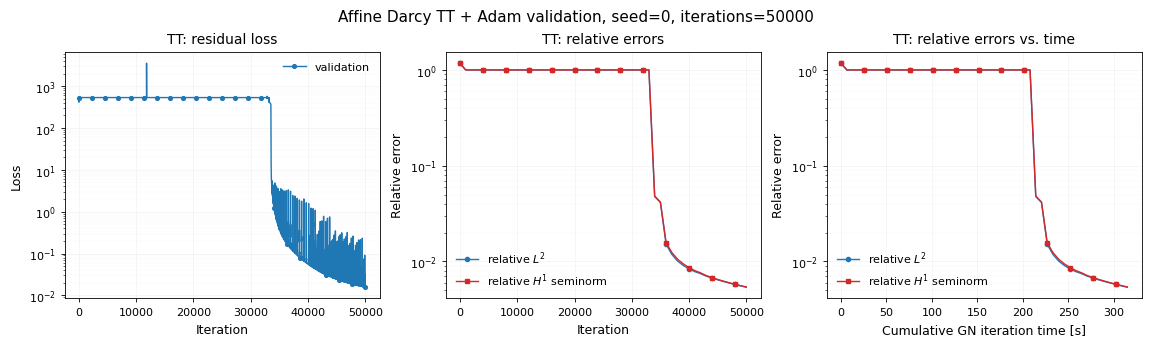

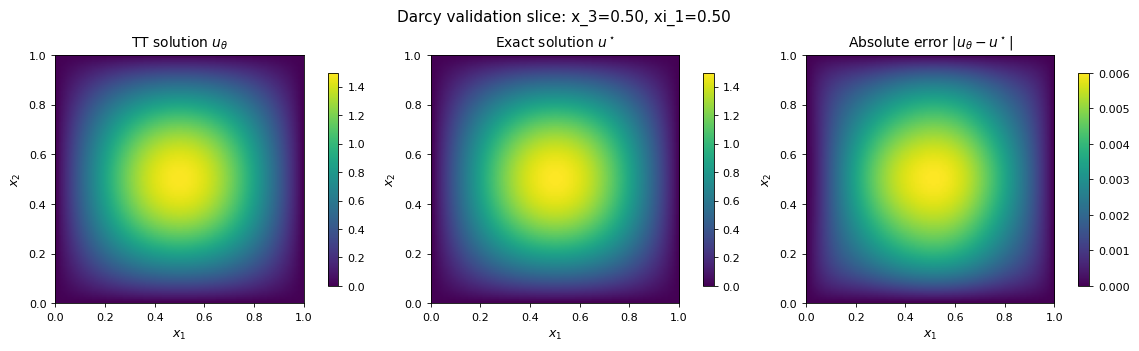

(<Figure size 1140x340 with 6 Axes>,
 array([<Axes: title={'center': 'TT solution $u_\\theta$'}, xlabel='$x_1$', ylabel='$x_2$'>,
        <Axes: title={'center': 'Exact solution $u^\\star$'}, xlabel='$x_1$', ylabel='$x_2$'>,
        <Axes: title={'center': 'Absolute error $|u_\\theta-u^\\star|$'}, xlabel='$x_1$', ylabel='$x_2$'>],
       dtype=object))

In [ ]:
# ------------------------------------------------------------
# Single TT + Adam validation run for the selected seed.
# ------------------------------------------------------------
validation_cfg = replace(
    BASE,
    seed=VALIDATION_SEED,
    iterations=VALIDATION_ITERATIONS,
    error_every=VALIDATION_ERROR_EVERY,
)

(
    validation_solver,
    validation_theta,
    validation_scales,
    validation_record,
    validation_history,
) = run(validation_cfg, verbose=True, live_progress=True)

print()
print(f"final relative L2 error:             {validation_record['l2_final']:.4e}")
print(f"best relative L2 error:              {validation_record['l2_best']:.4e}")
print(f"final relative H1 error:             {validation_record['h1_final']:.4e}")
print(f"best relative H1 error:              {validation_record['h1_best']:.4e}")
print(f"final relative H1-seminorm error:    {validation_record['h1_seminorm_final']:.4e}")
print(f"final residual loss:                 {validation_record['loss_final']:.4e}")
print(f"time per Adam iteration:             {1e3 * validation_record['t_per_iter']:.2f} ms")
print(f"compiled Adam iteration time:        {validation_record['t_run']:.3f} s")
print(f"compilation time:                    {validation_record['t_compile']:.3f} s")

validation_stem = Path(VALIDATION_RESULT_DIR) / (
    f"darcy_affine_adam_tt_validation_seed_{VALIDATION_SEED}"
)
plot_tt_history(
    validation_history,
    title=(
        rf"Affine Darcy TT + Adam validation, seed={VALIDATION_SEED}, "
        rf"iterations={VALIDATION_ITERATIONS}"
    ),
    save_stem=validation_stem,
)

validation_slice_stem = Path(VALIDATION_RESULT_DIR) / (
    f"darcy_affine_adam_tt_validation_slice_seed_{VALIDATION_SEED}"
)
plot_validation_solution_slice(
    validation_solver,
    validation_theta,
    validation_scales,
    xi=VALIDATION_SLICE_XI,
    fixed_physical=VALIDATION_SLICE_FIXED_PHYS,
    n=VALIDATION_SLICE_N,
    save_stem=validation_slice_stem,
)

## Consistency checks

Pointwise checks of the exact solution, coefficient and forcing, of the TT contractions against
automatic differentiation, and of the hard boundary constraint. The last check compares the
compressed gradient with reverse-mode automatic differentiation. All errors should be at round-off
level.

In [ ]:
# ------------------------------------------------------------
# Analytical and contraction checks.
# These points are diagnostics only; training uses axis-wise factor grids.
# ------------------------------------------------------------
check_key = random.PRNGKey(2026)
unit = random.uniform(check_key, (5, BASE.d))
check_points = unit.at[:, D_PHYS:].set(2.0 * unit[:, D_PHYS:] - 1.0)

exact_value = lambda z: problem.exact(z)[0]
exact_output = vmap(problem.exact)(check_points)
exact_grad_error = float(jnp.max(jnp.abs(
    vmap(jax.grad(exact_value))(check_points)[:, :D_PHYS] - exact_output[1]
)))
exact_lap_error = float(jnp.max(jnp.abs(
    vmap(lambda z: jnp.trace(
        jax.hessian(exact_value)(z)[:D_PHYS, :D_PHYS]
    ))(check_points) - exact_output[2]
)))
kappa_grad_error = float(jnp.max(jnp.abs(
    vmap(jax.grad(lambda z: problem.kappa(z)[0]))(check_points)[:, :D_PHYS]
    - vmap(problem.kappa)(check_points)[1]
)))

# Verify the exact forcing represented by the separable operator chain.
forcing_chain_error = float(jnp.max(jnp.abs(
    vmap(validation_solver.exact_forcing_from_chain)(check_points)
    - vmap(problem.forcing)(check_points)
)))

model_value = lambda z: validation_solver.ansatz.evaluate_all(
    validation_theta, validation_scales, z
)[0]
model_output = vmap(lambda z: validation_solver.ansatz.evaluate_all(
    validation_theta, validation_scales, z
))(check_points)
model_grad_error = float(jnp.max(jnp.abs(
    model_output[1]
    - vmap(jax.grad(model_value))(check_points)[:, :D_PHYS]
)))
model_lap_error = float(jnp.max(jnp.abs(
    model_output[2]
    - vmap(lambda z: jnp.trace(
        jax.hessian(model_value)(z)[:D_PHYS, :D_PHYS]
    ))(check_points)
)))

print(f"exact gradient error:          {exact_grad_error:.3e}")
print(f"exact Laplacian error:         {exact_lap_error:.3e}")
print(f"permeability gradient error:   {kappa_grad_error:.3e}")
print(f"separable forcing-chain error: {forcing_chain_error:.3e}")
print(f"TT contraction gradient error: {model_grad_error:.3e}")
print(f"TT contraction Laplacian error:{model_lap_error:.3e}")


# The exact solution uses sine factors, whereas the neural ansatz uses only
# the polynomial cutoff. Both must vanish on the physical boundary.
boundary_points = check_points[:2]
boundary_points = boundary_points.at[0, 0].set(0.0)
boundary_points = boundary_points.at[1, 0].set(1.0)
exact_boundary_error = float(jnp.max(jnp.abs(vmap(exact_value)(boundary_points))))
model_boundary_error = float(jnp.max(jnp.abs(vmap(model_value)(boundary_points))))

print(f"exact boundary error:          {exact_boundary_error:.3e}")
print(f"neural hard-boundary error:    {model_boundary_error:.3e}")

# Exact TT cores (ranks 1, 2, ..., 2, 1) reproduce u*_aff.
def _exact_tt_value(z):
    U = problem.exact_cores(z[:, None])[:, 0, 0]
    state = jnp.array([1.0, 0.0])
    for m in range(BASE.d):
        state = state @ U[m]
    return state[0]

exact_tt_error = float(jnp.max(jnp.abs(vmap(_exact_tt_value)(check_points) - exact_output[0])))
print(f"exact TT-core value error:     {exact_tt_error:.3e}")

# Compressed dimension of the validation solver vs. the affine Darcy proposition.


# Compressed gradient C^T rho_c versus reverse-mode differentiation of the loss.
_grids = problem.sample_factor_grids(random.PRNGKey(7), N_PER_AXIS)
_loss, _g = validation_solver.loss_and_gradient(validation_theta, _grids, validation_scales)
_ga = validation_solver.autodiff_gradient(validation_theta, _grids, validation_scales)
_flat = lambda tree: jnp.concatenate([x.reshape(-1) for x in jax.tree_util.tree_leaves(tree)])
_grad_error = float(jnp.max(jnp.abs(_flat(_g) - _flat(_ga))) / jnp.max(jnp.abs(_flat(_ga))))
print(f"compressed gradient vs autodiff (relative max error): {_grad_error:.3e}")
print(
    f"compressed-gradient dimension N_eff^ch = {validation_solver.N_eff} "
    f"(formula: {compressed_gradient_dimension(D_PHYS, D_PARAM, N_PER_AXIS, validation_solver.ansatz.rank)})"
)

exact gradient error:          4.441e-16
exact Laplacian error:         3.553e-15
permeability gradient error:   1.110e-16
separable forcing-chain error: 5.329e-15
TT contraction gradient error: 1.332e-15
TT contraction Laplacian error:8.882e-15
exact boundary error:          1.077e-16
neural hard-boundary error:    0.000e+00
exact TT-core value error:     3.331e-16
compressed gradient vs autodiff (relative max error): 2.849e-12
compressed-gradient dimension N_eff^ch = 8192 (formula: 8192)


## Seed ablation

The first cell trains every case in `ABLATION_CASES` for every seed in `ABLATION_SEEDS`. The next
cell plots the results and exports per-seed and summary tables together with the full histories.

In [ ]:
# ------------------------------------------------------------
# Run the TT + Adam random-seed ablation for all cases.
# No plotting is done here.
# ------------------------------------------------------------
if RUN_ABLATION:
    ablation_results = {}
    for d_phys, d_param in ABLATION_CASES:
        case_key = case_label(d_phys, d_param)
        ablation_results[case_key] = {}
        print()
        print("=" * 88)
        print(
            f"Starting TT + Adam ablation case {case_key} with {len(ABLATION_SEEDS)} seeds, "
            f"iterations={ABLATION_ITERATIONS}, error every {ABLATION_ERROR_EVERY}"
        )
        print("=" * 88)
        for seed in ABLATION_SEEDS:
            seed = int(seed)
            cfg = replace(
                BASE,
                d_phys=int(d_phys),
                d_param=int(d_param),
                seed=seed,
                iterations=ABLATION_ITERATIONS,
                error_every=ABLATION_ERROR_EVERY,
            )
            can_reuse_validation = (
                REUSE_VALIDATION_IN_ABLATION
                and "validation_cfg" in globals()
                and cfg == validation_cfg
                and "validation_record" in globals()
            )
            if can_reuse_validation:
                print(f"[TT/Adam] case={case_key} seed={seed}: reusing validation run")
                record, history = validation_record, validation_history
            else:
                ab_solver, ab_theta, ab_scales, record, history = run(cfg, verbose=True)
                del ab_solver, ab_theta, ab_scales
            ablation_results[case_key][seed] = {"record": record, "history": history}
            gc.collect()
            if CLEAR_JAX_CACHES_BETWEEN_RUNS and not can_reuse_validation:
                jax.clear_caches()

    total_runs = len(ABLATION_CASES) * len(ABLATION_SEEDS)
    print(f"\nTT + Adam ablation completed: {total_runs} runs.")
    print("Run the next cell to plot, summarize, and export the results.")
else:
    ablation_results = {}
    print("Ablation skipped because RUN_ABLATION=False.")


Starting TT + Adam ablation case 3+25 with 10 seeds, iterations=50000, error every 1000
[TT/Adam] case=3+25 seed=0: reusing validation run
[TT/Adam] seed=10 d=28=3+25 rank=2 P=945772 | L2=4.682e-03 H1=4.710e-03 grad=4.711e-03 | 6.29 ms/it, 314.5 s
[TT/Adam] seed=20 d=28=3+25 rank=2 P=945772 | L2=8.062e-03 H1=8.156e-03 grad=8.159e-03 | 6.27 ms/it, 313.6 s
[TT/Adam] seed=30 d=28=3+25 rank=2 P=945772 | L2=1.000e+00 H1=1.000e+00 grad=1.000e+00 | 6.36 ms/it, 318.0 s
[TT/Adam] seed=40 d=28=3+25 rank=2 P=945772 | L2=6.574e-03 H1=6.590e-03 grad=6.590e-03 | 6.26 ms/it, 312.9 s
[TT/Adam] seed=50 d=28=3+25 rank=2 P=945772 | L2=1.039e-02 H1=1.043e-02 grad=1.043e-02 | 6.29 ms/it, 314.3 s
[TT/Adam] seed=60 d=28=3+25 rank=2 P=945772 | L2=1.589e-02 H1=1.653e-02 grad=1.655e-02 | 6.27 ms/it, 313.7 s
[TT/Adam] seed=70 d=28=3+25 rank=2 P=945772 | L2=6.515e-03 H1=6.516e-03 grad=6.516e-03 | 6.36 ms/it, 318.0 s
[TT/Adam] seed=80 d=28=3+25 rank=2 P=945772 | L2=3.909e-03 H1=3.924e-03 grad=3.924e-03 | 6.26 ms/

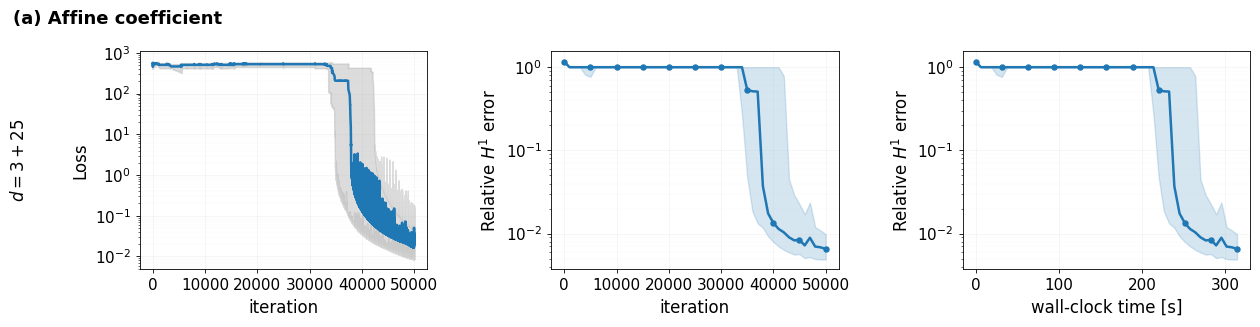

saved convergence figure: darcy_affine_adam_tt_multicase_seed_ablation_convergence.png and darcy_affine_adam_tt_multicase_seed_ablation_convergence.pdf


In [ ]:
# ------------------------------------------------------------
# Plot and export the completed TT + Adam ablation.
# This cell does not train.
# ------------------------------------------------------------
if not RUN_ABLATION:
    raise RuntimeError("Set RUN_ABLATION=True and run the preceding cell first.")

result_dir = Path(ABLATION_RESULT_DIR)
result_dir.mkdir(parents=True, exist_ok=True)

rows = []
summary_rows = []
missing = [case_label(*c) for c in ABLATION_CASES if case_label(*c) not in ablation_results]
if missing:
    raise RuntimeError(f"TT + Adam ablation is incomplete; missing cases: {missing}")

stem = result_dir / "darcy_affine_adam_tt_multicase_seed_ablation_convergence"
plot_tt_multicase_ablation(
    ablation_results,
    ABLATION_CASES,
    ABLATION_SEEDS,
    title=(
        rf"Affine Darcy TT + Adam seed ablation, {len(ABLATION_SEEDS)} seeds per case, "
        rf"iterations={ABLATION_ITERATIONS}"
    ),
    save_stem=stem,
)
print(f"saved convergence figure: {stem}.png and {stem}.pdf")

for d_phys, d_param in ABLATION_CASES:
    key = case_label(d_phys, d_param)
    case_rows = []
    for seed in ABLATION_SEEDS:
        record = ablation_results[key][int(seed)]["record"]
        row = {
            "format": "TT",
            "optimizer": "Adam",
            "case": key,
            "d_phys": int(d_phys),
            "d_param": int(d_param),
            "total_dimension": int(d_phys + d_param),
            "seed": int(seed),
            "rank": record["rank"],
            "relative_L2_final": record["l2_final"],
            "relative_H1_final": record["h1_final"],
            "relative_H1_seminorm_final": record["h1_seminorm_final"],
            "relative_L2_best": record["l2_best"],
            "relative_H1_best": record["h1_best"],
            "loss_final": record["loss_final"],
            "wall_clock_time_s": record["t_run"],
            "ms_per_iteration": 1e3 * record["t_per_iter"],
            "iterations": record["iterations"],
            "adam_lr": record["adam_lr"],
            "adam_lr_final": record["adam_lr_final"],
            "parameters": record["P"],
            "N_eff_gradient": record["N_eff"],
            "n_per_axis": record["n_per_axis"],
            "sampling_policy": record["sampling_policy"],
        }
        rows.append(row)
        case_rows.append(row)
    case_table = pd.DataFrame(case_rows)
    summary_rows.append({
        "format": "TT",
        "optimizer": "Adam",
        "case": key,
        "d_phys": int(d_phys),
        "d_param": int(d_param),
        "avg_relative_L2_final": case_table["relative_L2_final"].mean(),
        "std_relative_L2_final": case_table["relative_L2_final"].std(ddof=1),
        "avg_relative_H1_final": case_table["relative_H1_final"].mean(),
        "std_relative_H1_final": case_table["relative_H1_final"].std(ddof=1),
        "median_relative_H1_final": case_table["relative_H1_final"].median(),
        "avg_wall_clock_time_s": case_table["wall_clock_time_s"].mean(),
        "std_wall_clock_time_s": case_table["wall_clock_time_s"].std(ddof=1),
        "avg_ms_per_iteration": case_table["ms_per_iteration"].mean(),
        "std_ms_per_iteration": case_table["ms_per_iteration"].std(ddof=1),
    })

ablation_table = pd.DataFrame(rows).sort_values(["format", "d_phys", "d_param", "seed"])
summary_table = pd.DataFrame(summary_rows).sort_values(["format", "d_phys", "d_param"])
_fmt_cols = {c: "{:.4e}" for c in ablation_table.columns if c.startswith("relative") or c == "loss_final"}
_fmt_cols.update({"wall_clock_time_s": "{:.1f}", "ms_per_iteration": "{:.2f}"})
display(ablation_table.style.format(_fmt_cols))
_sum_cols = {c: "{:.4e}" for c in summary_table.columns if "relative" in c}
_sum_cols.update({c: "{:.2f}" for c in summary_table.columns if "time" in c or "ms_per" in c})
display(summary_table.style.format(_sum_cols))

csv_path = result_dir / "darcy_affine_adam_seed_ablation.csv"
summary_csv_path = result_dir / "darcy_affine_adam_seed_ablation_summary.csv"
json_path = result_dir / "darcy_affine_adam_seed_ablation_histories.json"
ablation_table.to_csv(csv_path, index=False)
summary_table.to_csv(summary_csv_path, index=False)

payload = {
    "settings": {
        "validation_base": asdict(BASE),
        "cases": [{"d_phys": int(a), "d_param": int(b), "label": case_label(a, b)} for a, b in ABLATION_CASES],
        "seeds": [int(seed) for seed in ABLATION_SEEDS],
        "iterations": int(ABLATION_ITERATIONS),
        "error_every": int(ABLATION_ERROR_EVERY),
        "method": "TT + Adam, compressed gradient C^T rho_c (no Gauss--Newton, no line search)",
        "adam": {"lr": ADAM_LR, "lr_final": ADAM_LR_FINAL, "schedule": "exponential",
                  "beta1": ADAM_BETA1, "beta2": ADAM_BETA2, "eps": ADAM_EPS},
        "collocation": "axis-wise factor grids; implied tensor grid never formed",
        "hard_boundary_factor": "sqrt(30)*x*(1-x)",
    },
    "runs": {
        case_label(a, b): {
            str(seed): {
                "record": ablation_results[case_label(a, b)][int(seed)]["record"],
                "history": json_history(ablation_results[case_label(a, b)][int(seed)]["history"]),
            }
            for seed in ABLATION_SEEDS
        }
        for a, b in ABLATION_CASES
    },
}
with open(json_path, "w") as file:
    json.dump(payload, file, indent=2)

print(f"saved per-seed table:     {csv_path}")
print(f"saved summary table:      {summary_csv_path}")
print(f"saved complete histories: {json_path}")